<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/AULA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#importar base de dados
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [4]:
#ler o arquivo csv
df= pd.read_csv("iiot_30min_norm.csv")

In [7]:
#exibir informacoes basicas
print (f"dimensoes dodataset: df.shape")
print(f"/n primeiras linhas do dataset:/ n(df.head())")

dimensoes dodataset: df.shape
/n primeiras linhas do dataset:/ n(df.head())


In [9]:
#selecionar apenas colunas numericas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['FM1', 'PE1', 'PE2', 'PE3', 'PE4', 'TP1', 'TP2', 'EPOCH']

In [11]:
#selecionar as colunas numericas para um modelo
x= df[numeric_cols]
y=df["PE1"]

In [12]:
#VERIFICAR VALORES FALTANTES EM CADA COLUNA
cols_to_remove=[]
for col in x.columns:
  missing_count= x[col].isna().sum()
  if missing_count > 0 :
    cols_to_remove.append(col)
cols_to_remove



[]

In [14]:
for col in cols_to_remove:
  x=x.drop(col, axis=1)

In [15]:
#remover target to x
x=x.drop("PE1", axis=1)

In [17]:
#dividir em conjunto detreinamento e de validacao
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3 , random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression, Ridge , Lasso

In [21]:
#treinar a regressao linear
model_val_cruz= LinearRegression()
model_val_cruz.fit(x_train, y_train)

LinearRegression()

In [22]:
#fazer predicoes no conjunto de validacao (test)
y_pred= model_val_cruz.predict(x_test)


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
#calcular
r2_val_cruz= r2_score(y_test, y_pred)
mse_val_cruz= mean_squared_error(y_test, y_pred)

In [25]:
print(f"r2 scores: (r2_val_cruz)")
print(f"mse: (mse_val_cruz)")

r2 scores: (r2_val_cruz)
mse: (mse_val_cruz)


In [26]:
#utilizar o metodo de k-fold cross validation
k=10
n_samples= len(x)
fold_size= n_samples//k
cv_scores=[]


In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

for fold in range(k):
  print(f"fold {fold + 1}")
  start_idx=fold*fold_size
  end_idx= start_idx + fold_size if fold< k-1 else n_samples
  test_ind_fold=list (range(start_idx, end_idx))
  train_ind_fold=list (range(0, start_idx))+list(range(end_idx, n_samples))

  #separar dados
  x_train_fold=x.iloc[train_ind_fold]
  y_train_fold=y.iloc[train_ind_fold]
  x_test_fold=x.iloc[test_ind_fold]
  y_test_fold=y.iloc[test_ind_fold]

  #treinar o modelo e prever o test
  model_fold= LinearRegression()
  model_fold.fit(x_train_fold, y_train_fold)
  y_pred_fold=model_fold.predict(x_test_fold)

  #calcular as metricas do fold
  mse_fold=mean_squared_error (y_test_fold, y_pred_fold)
  mae_fold=mean_absolute_error(y_test_fold, y_pred_fold)
  r2_fold=r2_score( y_test_fold, y_pred_fold)

  cv_scores.append({
      'fold': fold + 1,
      'mse': mse_fold,
      'mae': mae_fold,
      'r2': r2_fold
  })

fold 1
fold 2
fold 3
fold 4
fold 5
fold 6
fold 7
fold 8
fold 9
fold 10


In [31]:
#exibir metricas
r2_scores = [score['r2'] for score in cv_scores]
print(f"\n scores r2 para cada fold: {r2_scores} ")
print(f"\n media r2: {np.mean(r2_scores)}")
print(f"\ndesvio padrao r2: {np.std(r2_scores)}")


 scores r2 para cada fold: [0.5867031128847351, 0.2014884368407992, 0.07291195377823756, -0.3086143013388294, 0.11808127283119707, -1.4382299928836737, -0.27477558654156997, 0.4197364336813679, -0.1694448885995421, 0.6591656452877499] 

 media r2: -0.013297791405952853

desvio padrao r2: 0.5727956594304455


In [32]:
r2_scores = [score['r2'] for score in cv_scores]
np.mean(r2_scores)

np.float64(-0.013297791405952853)

In [33]:
#bootstrap
n_bootstraps= 100
n_samples=len(x)
r2_score_boot=[]
coeficients_boot=[]



In [36]:
#executar o bootstrap
for i in range(n_bootstraps):
  print(f"executando iteracao {i+1}")

  #amostragem
  bootstrap_ind=np.random.choice(range(n_samples), n_samples, replace=True)
  x_boot=x.iloc[bootstrap_ind]
  y_boot=y.iloc[bootstrap_ind]

  #treinar um modelo para cada um
  model_boot=LinearRegression()
  model_boot.fit(x_boot, y_boot)

  #fazer predicoes
  y_pred_boot=model_boot.predict(x_test)

  #calcular r2
  r2_boot=r2_score(y_test,y_pred_boot)
  r2_score_boot.append(r2_boot)
  #calcular coeficients
  coeficients_boot.append(model_boot.coef_)

executando iteracao 1
executando iteracao 2
executando iteracao 3
executando iteracao 4
executando iteracao 5
executando iteracao 6
executando iteracao 7
executando iteracao 8
executando iteracao 9
executando iteracao 10
executando iteracao 11
executando iteracao 12
executando iteracao 13
executando iteracao 14
executando iteracao 15
executando iteracao 16
executando iteracao 17
executando iteracao 18
executando iteracao 19
executando iteracao 20
executando iteracao 21
executando iteracao 22
executando iteracao 23
executando iteracao 24
executando iteracao 25
executando iteracao 26
executando iteracao 27
executando iteracao 28
executando iteracao 29
executando iteracao 30
executando iteracao 31
executando iteracao 32
executando iteracao 33
executando iteracao 34
executando iteracao 35
executando iteracao 36
executando iteracao 37
executando iteracao 38
executando iteracao 39
executando iteracao 40
executando iteracao 41
executando iteracao 42
executando iteracao 43
executando iteracao 

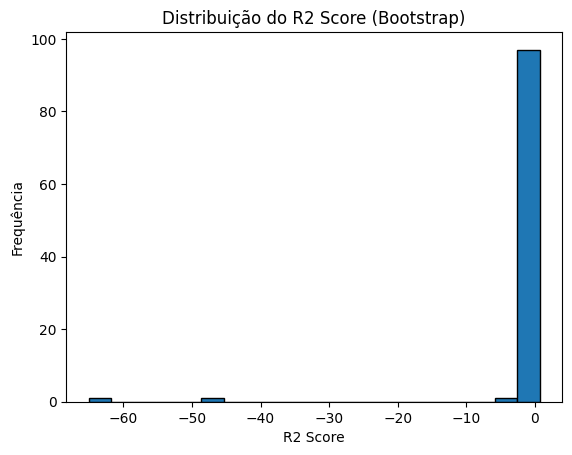

In [38]:
#histograma do r2 score
sorted_r2= np.sort(r2_score_boot)
plt.hist(r2_score_boot, bins=20, edgecolor='black')
plt.title('Distribuição do R2 Score (Bootstrap)')
plt.xlabel('R2 Score')
plt.ylabel('Frequência')
plt.show()

In [39]:
r2_score_boot

[0.5717329029846603,
 0.6401624288089444,
 0.6736143456729164,
 -2.7356821183738176,
 0.6074970321474455,
 0.6422481792271293,
 0.6758124467083928,
 0.6730037577551462,
 0.6207031365079475,
 0.6587492061571749,
 0.6613213455169447,
 0.6671609962737584,
 0.6432506150632158,
 0.6610212124377168,
 0.6071031569952248,
 0.6710173440471003,
 0.6490530370452039,
 0.6813053541696994,
 0.681581637382036,
 0.6497428741368492,
 0.6444264722419302,
 0.6730884373640145,
 0.6609474368596311,
 0.6401672646037411,
 0.6852377707540479,
 0.6875873915417626,
 0.6258669477300114,
 0.6390042650938706,
 0.6670431665847949,
 0.6256455919171902,
 0.6673399565903317,
 0.675332090566961,
 0.6645844811784716,
 0.6621081373189899,
 0.6566506399534306,
 0.6607969049242173,
 0.6738968694317665,
 0.6627916685404698,
 0.6581896003952606,
 0.6750462199151646,
 0.6597921561002607,
 0.6402465021349679,
 0.6591986941945807,
 0.6066305064593078,
 0.6479114797089218,
 0.6403593344261143,
 0.6817793292157411,
 0.66858853691

In [40]:
#selecao dee modelos
#forward selection

current_features=[]
remaind_features=x.columns.tolist()
best_r2= 0
significante_level=0.05

In [42]:
import statsmodels.api as sm

In [44]:
#fazer op rocesso forward selection
iteration= 1
while remaind_features:
  print(f"iteration: {iteration}\n")
  best_new_feature= None
  best_new_score= -np.inf
  best_pvalue=1.0

  #testar cada feature
  for feature in remaind_features:
    test_features= current_features + [feature]
    x_temp = x[test_features]
    x_temp_constant=sm.add_constant(x_temp)

    #treinar o modelo
    model = sm.OLS(y, x_temp_constant).fit()

    #obter o r2 ajustado e p-value
    adjusted_r2 = model.rsquared_adj
    pvalue = model.pvalues[feature]

    #verificar se a feature melhora o modelo e e significativa
    if adjusted_r2 > best_new_score and pvalue < significante_level:
      best_new_score= adjusted_r2
      best_new_feature= feature
      best_pvalue = pvalue

  #adicionar a melhor feature
  if best_new_feature:
    current_features.append(best_new_feature)
    remaind_features.remove(best_new_feature)
    print(f"adicionando feature: {best_new_feature} (Adjusted R2: {best_new_score:.4f}, p-value: {best_pvalue:.4f})")
  else:
    print("nenhuma feature adicional melhora o modelo de forma significativa.")
    break
  iteration += 1

print("\nfeatures selecionadas:")
print(current_features)

iteration: 1

adicionando feature: PE4 (Adjusted R2: 0.2335, p-value: 0.0000)
iteration: 2

adicionando feature: PE3 (Adjusted R2: 0.4855, p-value: 0.0000)
iteration: 3

adicionando feature: FM1 (Adjusted R2: 0.5459, p-value: 0.0000)
iteration: 4

adicionando feature: EPOCH (Adjusted R2: 0.6090, p-value: 0.0000)
iteration: 5

adicionando feature: PE2 (Adjusted R2: 0.6385, p-value: 0.0000)
iteration: 6

adicionando feature: TP2 (Adjusted R2: 0.6518, p-value: 0.0000)
iteration: 7

adicionando feature: TP1 (Adjusted R2: 0.6537, p-value: 0.0295)

features selecionadas:
['PE4', 'PE3', 'FM1', 'EPOCH', 'PE2', 'TP2', 'TP1']
